(np.float64(-0.5), np.float64(590.5), np.float64(486.5), np.float64(-0.5))

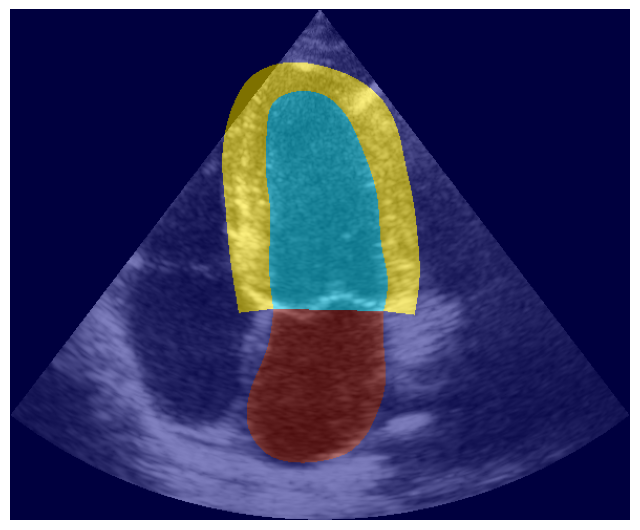

In [1]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import json
import pandas as pd
import networkx as nx
from collections import defaultdict
import os

image_list_path = Path("../Dataset/CAMUS/Landmarks_3_10") / 'image_list.txt'
with open(image_list_path, 'r') as f:
    image_list = f.read().splitlines()

image_path = Path("../Dataset/CAMUS/Landmarks_3_10") / 'images' / image_list[253]
mask_path = Path("../Dataset/CAMUS/Landmarks_3_10") / 'masks' / image_list[253]

image = cv2.imread(str(image_path))
mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE) 
original_mask = mask.copy()

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray')
plt.imshow(mask, alpha=0.5, cmap='jet')
plt.axis('off')

In [2]:
from utils.unified_graph_utils import build_unified_contour_graph, create_unified_adjacency_matrix

masks = [mask.copy()]

# Main code

all_graphs = []

for mask in masks:
    G = build_unified_contour_graph(mask)    
    all_graphs.append(G)
    
# Combine all graphs into a single unified graph
# These are disjoint graphs, so we cannot use nx.compose directly
G = nx.Graph()
for graph in all_graphs:
    G = nx.disjoint_union(G, graph)

# Create the unified adjacency matrix
unified_adj_matrix, organ_membership = create_unified_adjacency_matrix(G)

# Print statistics
print(f"Unified adjacency matrix shape: {unified_adj_matrix.shape}")
print(f"Total nodes in graph: {G.number_of_nodes()}")

# Count shared nodes
shared_nodes = sum(1 for node in G.nodes() if len(G.nodes[node]['organs']) > 1)
print(f"Number of shared boundary points: {shared_nodes}")

# Count nodes per organ
organ_counts = defaultdict(int)
for node in G.nodes():
    for org in G.nodes[node]['organs']:
        organ_counts[org] += 1

print("\nNodes per organ:")
for org, count in organ_counts.items():
    print(f"Organ {org}: {count} nodes")

Processing organ ID: 1
Processing organ ID: 2
Processing organ ID: 3
Unified adjacency matrix shape: (759, 759)
Total nodes in graph: 759
Number of shared boundary points: 278

Nodes per organ:
Organ 1: 278 nodes
Organ 2: 533 nodes
Organ 3: 228 nodes


Drawing contours for organ 1 with 552 points
Drawing contours for organ 2 with 1064 points
Drawing contours for organ 3 with 451 points
Unique organ memberships: {'1-2', '1-2-3', '2', '1-3', '3'}


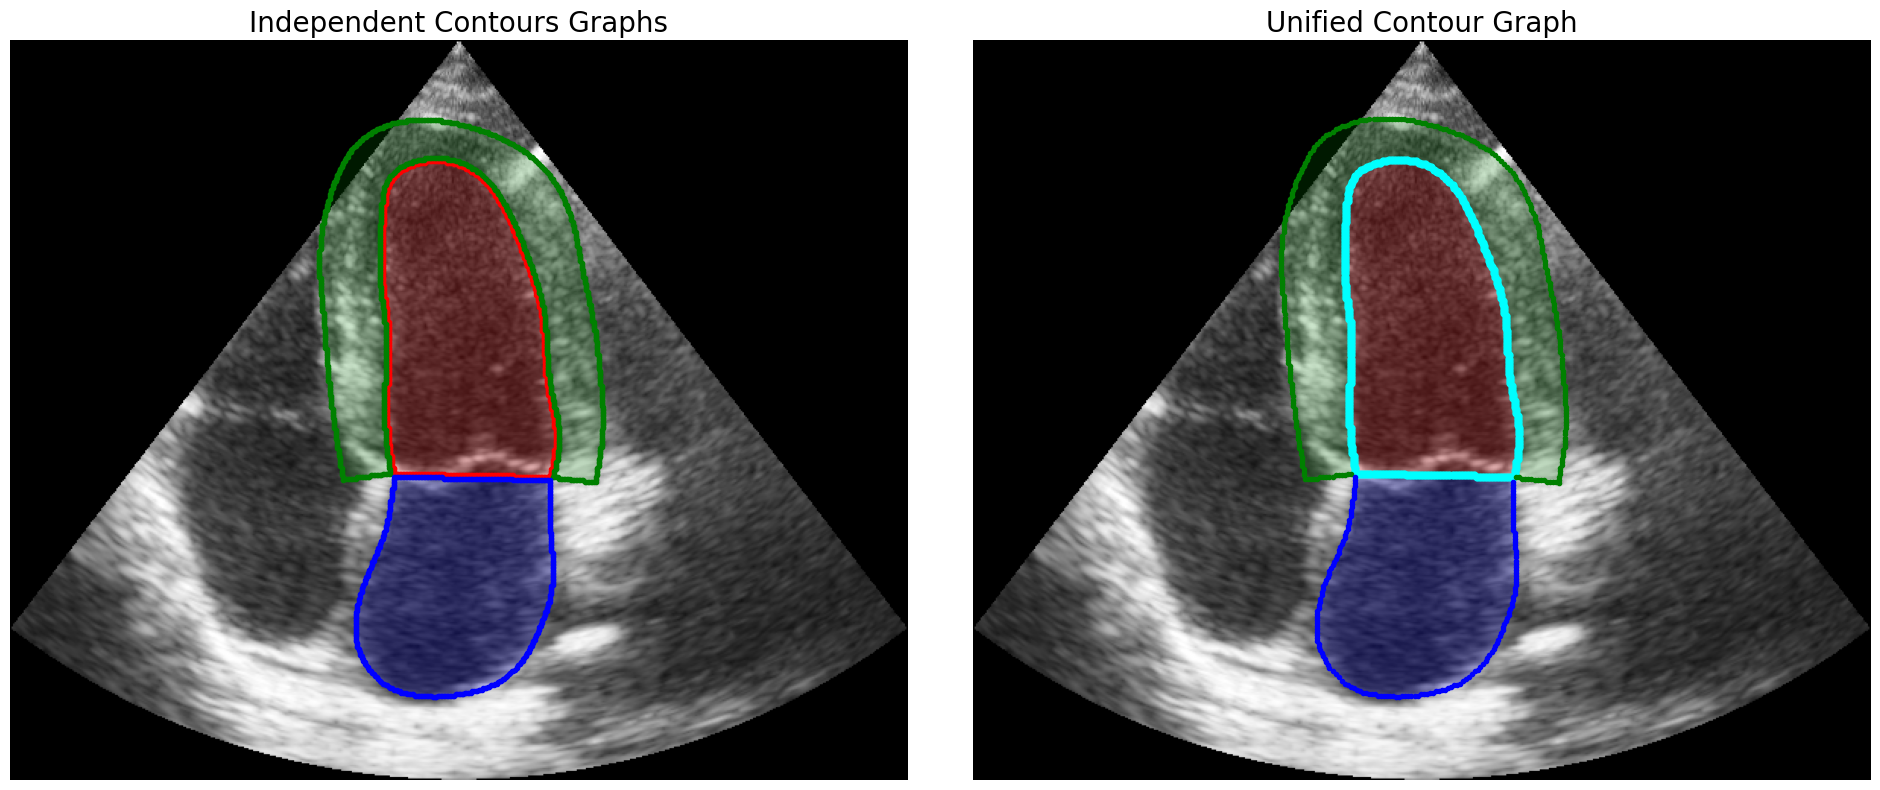

In [4]:
# Visualize the graph colored by organ membership
plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
# for each mask, draw the original contours
for m in range(1, np.max(original_mask) + 1):
    mask = (original_mask == m).astype(np.uint8) 
    # erode the mask to avoid overlapping contours
    mask = cv2.erode(mask, np.ones((2, 2), np.uint8), iterations=1)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    contours = np.array(contours[0], dtype=np.float32)
    print(f"Drawing contours for organ {m} with {len(contours)} points")
    
    if m == 1:
        plt.plot(contours[:, 0, 0], contours[:, 0, 1], 'o', markersize=3, label=f'Organ {m}', color='red')
    elif m == 2:
        plt.plot(contours[:, 0, 0], contours[:, 0, 1], 'o', markersize=3, label=f'Organ {m}', color='green')
    elif m == 3:
        plt.plot(contours[:, 0, 0], contours[:, 0, 1], 'o', markersize=3, label=f'Organ {m}', color='blue')

    plt.fill(contours[:, 0, 0], contours[:, 0, 1], alpha=0.2, color='red' if m == 1 else 'green' if m == 2 else 'blue')

# fill the inside of the contours


plt.title('Independent Contours Graphs', fontsize=20)
plt.axis('off')
plt.tight_layout()
# invert y-axis to match image coordinates

plt.subplot(1, 2, 2)
plt.imshow(image, cmap='gray')
pos = nx.get_node_attributes(G, 'pos')

# Draw edges
for u, v in G.edges():
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    plt.plot([x1, x2], [y1, y2], color='gray', linewidth=0.5, alpha=0.5)

# Draw nodes
for node in G.nodes():
    x, y = pos[node]
    organs = G.nodes[node]['organs']
    if len(organs) > 1:
        plt.plot(x, y, 'o', color="cyan", markersize=5)  # Shared nodes in red
    else:
        # Color based on organ ID
        organ_id = organs[0]
        if organ_id == 1:
            color = 'red'
        elif organ_id == 2:
            color = 'green'
        elif organ_id == 3:
            color = 'blue'
        plt.plot(x, y, 'o', color=color, markersize=3)

for m in range(1, np.max(original_mask) + 1):
    mask = (original_mask == m).astype(np.uint8)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    contours = np.array(contours[0], dtype=np.float32)
    plt.fill(contours[:, 0, 0], contours[:, 0, 1], alpha=0.2, color='red' if m == 1 else 'green' if m == 2 else 'blue')


plt.title('Unified Contour Graph', fontsize=20)
plt.axis('off')
plt.tight_layout()
# invert y-axis to match image coordinates
os.makedirs("../Dataset/CAMUS/Landmarks_3_10/Unified", exist_ok=True)
plt.savefig("../Dataset/CAMUS/Landmarks_3_10/Unified/contour_graphs.png", dpi=300, bbox_inches='tight')

# print the unique node memberships
unique_memberships = set(organ_membership)
print(f"Unique organ memberships: {unique_memberships}")

In [4]:
from utils.unified_graph_utils import downsample_one_step, generate_edge_info, save_matrices, unified_data_path

def generate_multi_organ_matrices(G, organ_membership, config, image):
    """
    Generate all matrices needed for multi-organ contour model,
    with naming conventions matching the original code
    """
    output_path = unified_data_path(config)
    # Set node attributes for organ membership
    for i, node in enumerate(G.nodes()):
        G.nodes[node]['organ_membership'] = organ_membership[i]
    
    # Get unique organ IDs
    all_organs = set()
    for membership in organ_membership:
        for org in membership.split('-'):
            if org:  # Skip empty strings
                all_organs.add(org)
    organ_ids = sorted(list(all_organs))
    
    # Determine resolution sizes
    num_resolutions = len(config['resolutions'])
    
    # Resolution sizes need to be 16 at minimum, then grow by factor of 2
    desired_sizes = [16 * (2 ** i) for i in range(num_resolutions)]
    print(f"Desired resolution sizes: {desired_sizes}")

    # Create directories
    os.makedirs(output_path, exist_ok=True)
    
    # Initialize collections, starting with first resolution size
    
    # Number of nodes 
    print(f"Initial graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    while G.number_of_nodes() > (16 * (2 ** (num_resolutions)) * len(config['organs'])):
        G, _, _, _ = downsample_one_step(G)
    print(f"Graph at new full resolution: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    
    graphs = [G]  
    downsampling_matrices = {}
    upsampling_matrices = {}
    
    # Process each resolution
    for i in range(num_resolutions - 1):
        curr_graph = graphs[i]
        curr_res = config['resolutions'][i]
        next_res = config['resolutions'][i+1]
        
        # Downsample to target size
        G_down, _, D, U = downsample_one_step(curr_graph)
        
        # Store results
        graphs.append(G_down)
        downsampling_matrices[f"to_{next_res}"] = D
        upsampling_matrices[f"to_{curr_res}"] = U
    
    # Save the atlas image and positions for pretraining
    pos = nx.get_node_attributes(graphs[0], 'pos')
    pos = pd.DataFrame(pos).T
    pos = pos.to_numpy()
    pos_path = Path(output_path) / 'atlas_pos.npy'
    np.save(pos_path, pos)
    image_path = Path(output_path) / 'atlas_image.png'
    cv2.imwrite(str(image_path), image)
        
    # Save matrices in compatible format
    for i, graph in enumerate(graphs):
        res = config['resolutions'][i]
        save_matrices(graph, res, config, organ_ids)
    
    # Save downsampling and upsampling matrices
    for key, matrix in downsampling_matrices.items():
        np.save(f"{output_path}/downsampling_{key}.npy", matrix)
    
    for key, matrix in upsampling_matrices.items():
        np.save(f"{output_path}/upsampling_{key}.npy", matrix)
    
    # Generate edge information for all resolutions
    generate_edge_info(config)
            
    return graphs, downsampling_matrices, upsampling_matrices

In [5]:
# Define configuration
config = {
    "output_path": "../Dataset/CAMUS/Landmarks_3_10",
    "resolutions": ["full", "half", "quarter"],
    "organs": ["1", "2", "3"]
}

# Run the pipeline on your graph
graphs, downsampling_matrices, upsampling_matrices = generate_multi_organ_matrices(
    G, organ_membership, config, image)

Desired resolution sizes: [16, 32, 64]
Initial graph: 759 nodes, 761 edges
Graph at new full resolution: 383 nodes, 385 edges


/tmp/ipykernel_231596/150268603.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


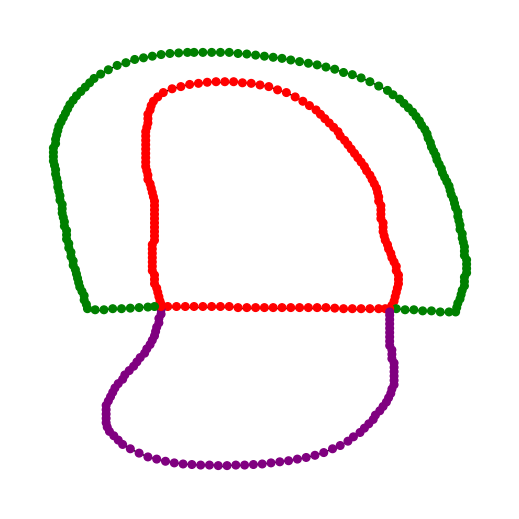

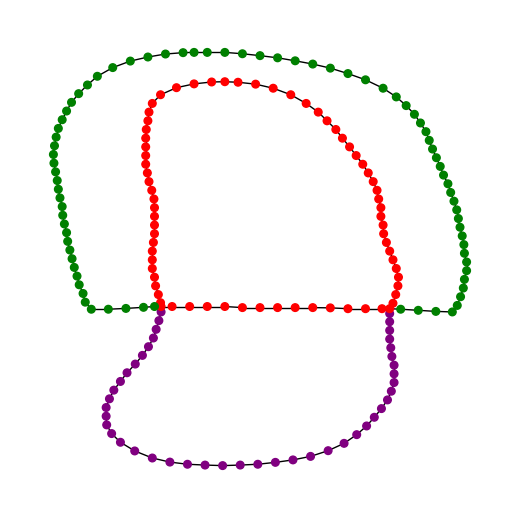

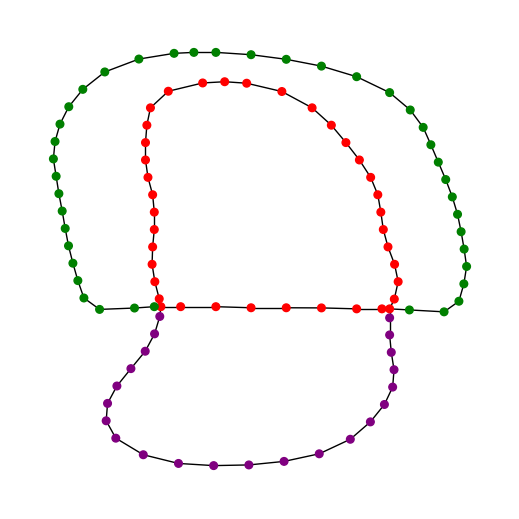

In [ ]:
# Visualize each resolution

plt.figure(figsize=(5, 5))

for i, graph in enumerate(graphs):
    
    pos = nx.get_node_attributes(graph, 'pos')
    
    # Color nodes by organ membership
    node_colors = []
    for node in graph.nodes():
        membership = graph.nodes[node]['organ_membership']
        if '-' in membership:  # Shared node
            node_colors.append('red')
        elif '1' in membership:
            node_colors.append('blue')
        elif '2' in membership:
            node_colors.append('green')
        else:
            node_colors.append('purple')
    
    nx.draw(graph, pos, node_color=node_colors, node_size=30)
    #plt.title(f"Resolution: {config['resolutions'][i]} - {graph.number_of_nodes()} nodes")
    plt.gca().invert_yaxis()  # Invert y-axis to match image coordinates
    plt.tight_layout()
plt.show()

(np.float64(179.8),
 np.float64(668.2),
 np.float64(450.525),
 np.float64(31.974999999999998))

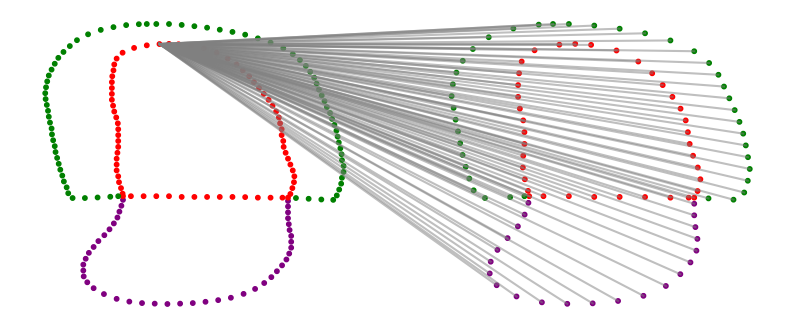

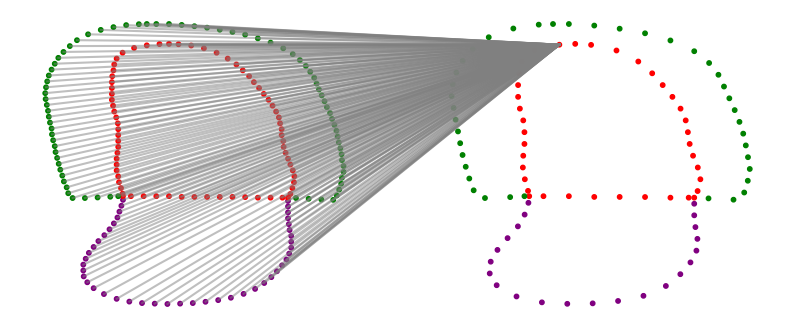

In [26]:
pos1 = nx.get_node_attributes(graphs[1], 'pos')
pos2 = nx.get_node_attributes(graphs[2], 'pos')

pos1 = pd.DataFrame(pos1).T
pos1 = pos1.to_numpy()
pos2 = pd.DataFrame(pos2).T
pos2 = pos2.to_numpy()
# draw the two point clouds next to each other in one plot

node_colors_1 = []
for node in graphs[1].nodes():
    membership = graphs[1].nodes[node]['organ_membership']
    if '-' in membership:  # Shared node
        node_colors_1.append('red')
    elif '1' in membership:
        node_colors_1.append('blue')
    elif '2' in membership:
        node_colors_1.append('green')
    else:
        node_colors_1.append('purple')
        
node_colors_2 = []
for node in graphs[2].nodes():
    membership = graphs[2].nodes[node]['organ_membership']
    if '-' in membership:  # Shared node
        node_colors_2.append('red')
    elif '1' in membership:
        node_colors_2.append('blue')
    elif '2' in membership:
        node_colors_2.append('green')
    else:
        node_colors_2.append('purple')

pos2 += np.array([[256, 0]])  # Shift second point cloud to the right        
plt.figure(figsize=(10, 4))
plt.scatter(pos1[:, 0], pos1[:, 1], c=node_colors_1, s=10, label='Resolution 1')
plt.scatter(pos2[:, 0], pos2[:, 1], c=node_colors_2, s=10, label='Resolution 2')

# draw lines between the two point clouds to depict chamfer loss
i = 0
for j in range(len(pos2)):
    plt.plot([pos1[i, 0], pos2[j, 0]], [pos1[i, 1], pos2[j, 1]], color='gray', alpha=0.5)
    
plt.gca().invert_yaxis()  # Invert y-axis to match image coordinates
plt.axis('off')

plt.figure(figsize=(10, 4))
plt.scatter(pos1[:, 0], pos1[:, 1], c=node_colors_1, s=10, label='Resolution 1')
plt.scatter(pos2[:, 0], pos2[:, 1], c=node_colors_2, s=10, label='Resolution 2')

# draw lines between the two point clouds to depict chamfer loss
j = 0
for i in range(len(pos1)):
    plt.plot([pos1[i, 0], pos2[j, 0]], [pos1[i, 1], pos2[j, 1]], color='gray', alpha=0.5)
    
plt.gca().invert_yaxis()  # Invert y-axis to match image coordinates
plt.axis('off')
